PROJECT 2: SURVEY DATA INVESTIGATION

Dataset: Stack Overflow Annual Developer Survey 2024

Objective:
To analyze salary, experience, remote work, job satisfaction,
and other patterns among technology professionals.

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats

In [3]:


df = pd.read_csv("Stack data 2024.csv")

# Display the first 5 rows of the dataset.
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [4]:
# check how many rows and columns are present in the dataset.

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 65437
Number of columns: 114


In [5]:


print(df.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith',

In [6]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [7]:


missing_values = df.isnull().sum()

# Sort missing values from highest to lowest.
missing_values = missing_values.sort_values(ascending=False)

# Display the top 20 columns with missing values.
print(missing_values.head(20))

AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
Knowledge_9                      37802
Frequency_3                      37727
Knowledge_8                      37679
ProfessionalTech                 37673
Knowledge_7                      37659
Knowledge_6                      37573
Knowledge_5                      37557
Knowledge_2                      37416
Knowledge_4                      37407
Knowledge_3                      37342
dtype: int64


In [8]:


duplicate_count = df.duplicated().sum()

# Display the total number of duplicate rows.
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:

df = df.drop_duplicates()

# Display the new dataset size after removing duplicates.
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (65437, 114)


In [10]:


important_columns = [
    "Age",
    "Employment",
    "RemoteWork",
    "EdLevel",
    "YearsCode",
    "YearsCodePro",
    "DevType",
    "OrgSize",
    "Country",
    "Currency",
    "CompTotal",
    "ConvertedCompYearly",
    "JobSat"
]

# Create a new dataframe using only the selected columns.
data = df[important_columns].copy()

# Display the first five rows of the selected data.
data.head()

,Age,Employment,RemoteWork,EdLevel,YearsCode,YearsCodePro,DevType,OrgSize,Country,Currency,CompTotal,ConvertedCompYearly,JobSat
0,Under 18 years old,"Employed, full-time",Remote,Primary/elementary school,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN
1,35-44 years old,"Employed, full-time",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",20,17,"Developer, full-stack",NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,NaN,NaN
2,45-54 years old,"Employed, full-time",Remote,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",37,27,Developer Experience,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,NaN,NaN
3,18-24 years old,"Student, full-time",NaN,Some college/university study without earning ...,4,NaN,"Developer, full-stack",NaN,Canada,NaN,NaN,NaN,NaN
4,18-24 years old,"Student, full-time",NaN,"Secondary school (e.g. American high school, G...",9,NaN,"Developer, full-stack",NaN,Norway,NaN,NaN,NaN,NaN


In [11]:


print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

# Display the names of the selected columns.
print("Selected columns:")
print(data.columns.tolist())

Number of rows: 65437
Number of columns: 13
Selected columns:
['Age', 'Employment', 'RemoteWork', 'EdLevel', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'Country', 'Currency', 'CompTotal', 'ConvertedCompYearly', 'JobSat']


In [12]:
data["ConvertedCompYearly"] = pd.to_numeric(
    data["ConvertedCompYearly"],
    errors="coerce"
)

# Display basic statistics of the yearly salary column.
print(data["ConvertedCompYearly"].describe())

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


In [13]:



data["YearsCodePro"] = pd.to_numeric(
    data["YearsCodePro"],
    errors="coerce"
)

# Display the first ten professional experience values.
print(data["YearsCodePro"].head(10))

0     NaN
1    17.0
2    27.0
3     NaN
4     NaN
5     NaN
6     7.0
7     NaN
8     NaN
9    11.0
Name: YearsCodePro, dtype: float64


In [14]:


data = data.dropna(
    subset=["ConvertedCompYearly", "YearsCodePro", "JobSat"]
)

# Display the number of rows remaining after cleaning.
print("Rows after cleaning:", data.shape[0])

Rows after cleaning: 15648


In [15]:


average_salary = data["ConvertedCompYearly"].mean()
median_salary = data["ConvertedCompYearly"].median()
minimum_salary = data["ConvertedCompYearly"].min()
maximum_salary = data["ConvertedCompYearly"].max()

# Display the calculated salary statistics.
print("Average salary:", round(average_salary, 2))
print("Median salary:", round(median_salary, 2))
print("Minimum salary:", round(minimum_salary, 2))
print("Maximum salary:", round(maximum_salary, 2))

Average salary: 87201.84
Median salary: 67635.0
Minimum salary: 1.0
Maximum salary: 13818022.0


In [16]:


salary_by_experience = (
    data.groupby("YearsCodePro")["ConvertedCompYearly"]
    .mean()
    .sort_index()
)

# Display the average salary for each experience level.
print(salary_by_experience)

YearsCodePro
1.0      32584.739771
2.0      44013.902721
3.0      49378.957478
4.0      56293.474114
5.0      63431.065021
6.0      74879.674952
7.0      94112.927847
8.0      85152.210011
9.0      88445.298561
10.0    112561.269991
11.0    116330.432099
12.0    105982.423948
13.0    126653.985542
14.0    103131.100559
15.0    112344.684314
16.0    113957.975232
17.0    111742.834507
18.0    116680.341818
19.0    128762.858639
20.0    114441.985782
21.0    119121.555556
22.0    121803.153846
23.0    130113.506849
24.0    125624.250000
25.0    135754.056680
26.0    125951.858268
27.0    112590.234694
28.0    128407.585859
29.0    127418.295455
30.0    151617.335570
31.0    149180.120000
32.0    111614.333333
33.0    124824.000000
34.0    140372.857143
35.0    136038.636364
36.0    141251.843750
37.0    128138.043478
38.0    136324.600000
39.0    129233.800000
40.0    160190.511628
41.0    113992.100000
42.0    150960.250000
43.0    164166.666667
44.0     99519.428571
45.0    125477.3125

In [17]:


job_satisfaction = data["JobSat"].value_counts().sort_index()

# Display the job satisfaction counts.
print(job_satisfaction)

# Calculate the average job satisfaction score.
average_job_satisfaction = data["JobSat"].mean()

# Display the average satisfaction score.
print("Average job satisfaction:", round(average_job_satisfaction, 2))

JobSat
0.0      166
1.0      153
2.0      442
3.0      646
4.0      647
5.0      984
6.0     2000
7.0     3418
8.0     4054
9.0     1962
10.0    1176
Name: count, dtype: int64
Average job satisfaction: 6.92


In [18]:


remote_work = data["RemoteWork"].value_counts()

# Display the remote work counts.
print(remote_work)

RemoteWork
Hybrid (some remote, some in-person)    6729
Remote                                  6405
In-person                               2510
Name: count, dtype: int64


In [19]:


remote_salary = (
    data.groupby("RemoteWork")["ConvertedCompYearly"]
    .mean()
    .sort_values(ascending=False)
)

# Display the average salary by remote work type.
print(remote_salary)

RemoteWork
Remote                                  97842.334270
Hybrid (some remote, some in-person)    85357.536781
In-person                               64949.495618
Name: ConvertedCompYearly, dtype: float64


In [20]:


country_count = data["Country"].value_counts()

# Select the top 10 countries.
top_countries = country_count.head(10)

# Display the top 10 countries.
print(top_countries)

Country
United States of America                                3170
Germany                                                 1386
United Kingdom of Great Britain and Northern Ireland     899
Ukraine                                                  796
India                                                    762
Canada                                                   581
France                                                   566
Brazil                                                   507
Poland                                                   417
Spain                                                    400
Name: count, dtype: int64


In [21]:


conn = sqlite3.connect("survey_database.db")

# Store the cleaned survey data in a table named 'survey'.
data.to_sql(
    "survey",
    conn,
    if_exists="replace",
    index=False
)

# Confirm that the database was created successfully.
print("SQLite database created successfully.")

SQLite database created successfully.


In [22]:


query1 = """
SELECT RemoteWork,
       AVG(ConvertedCompYearly) AS AverageSalary
FROM survey
WHERE ConvertedCompYearly IS NOT NULL
GROUP BY RemoteWork
ORDER BY AverageSalary DESC;
"""

# Execute the SQL query and store the result in a dataframe.
result1 = pd.read_sql_query(query1, conn)

# Display the query result.
result1

,RemoteWork,AverageSalary
0,None,115027.250000
1,Remote,97842.334270
2,"Hybrid (some remote, some in-person)",85357.536781
3,In-person,64949.495618


In [28]:


query2 = """
SELECT YearsCodePro,
       COUNT(*) AS Respondents,
       AVG(ConvertedCompYearly) AS AverageSalary
FROM survey
WHERE YearsCodePro IS NOT NULL
  AND ConvertedCompYearly IS NOT NULL
GROUP BY YearsCodePro
ORDER BY YearsCodePro;
"""

# Execute the SQL query.
result2 = pd.read_sql_query(query2, conn)

# Display the first 15 results.
result2.head(15)

,YearsCodePro,Respondents,AverageSalary
0,1.0,611,32584.739771
1,2.0,1213,44013.902721
2,3.0,1364,49378.957478
3,4.0,1101,56293.474114
4,5.0,1215,63431.065021
5,6.0,1046,74879.674952
6,7.0,887,94112.927847
7,8.0,919,85152.210011
8,9.0,556,88445.298561
9,10.0,1063,112561.269991


In [29]:


query3 = """
SELECT JobSat,
       COUNT(*) AS TotalRespondents
FROM survey
WHERE JobSat IS NOT NULL
GROUP BY JobSat
ORDER BY JobSat;
"""

# Execute the SQL query.
result3 = pd.read_sql_query(query3, conn)

# Display the query result.
result3

,JobSat,TotalRespondents
0,0.0,166
1,1.0,153
2,2.0,442
3,3.0,646
4,4.0,647
5,5.0,984
6,6.0,2000
7,7.0,3418
8,8.0,4054
9,9.0,1962


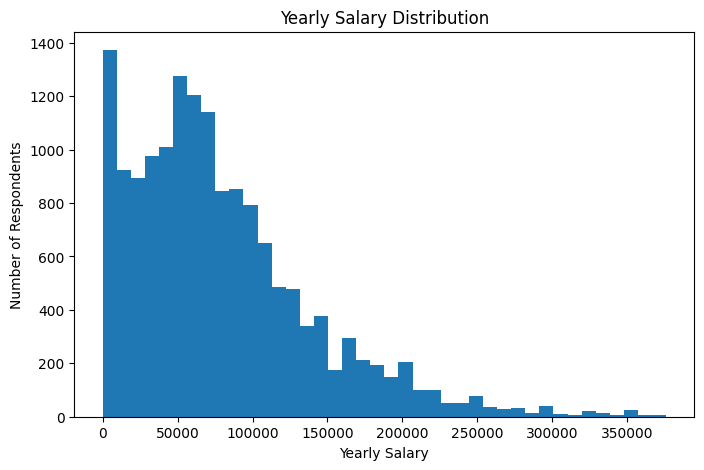

In [25]:


# Select valid salary values.
salary_data = data["ConvertedCompYearly"].dropna()

# Remove extreme values for better visualization.
salary_plot = salary_data[
    salary_data <= salary_data.quantile(0.99)
]

# Create the histogram.
plt.figure(figsize=(8, 5))
plt.hist(salary_plot, bins=40)

# Add labels and title.
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Respondents")
plt.title("Yearly Salary Distribution")

# Display the graph.
plt.show()

In [26]:


# Select all valid salary values.
salary = data["ConvertedCompYearly"].dropna()

# Calculate the sample mean.
mean_salary = salary.mean()

# Calculate the sample standard deviation.
std_salary = salary.std()

# Count the number of salary observations.
n = len(salary)

# Calculate the standard error.
standard_error = std_salary / np.sqrt(n)

# Calculate the t-value for a 95% confidence interval.
t_value = stats.t.ppf(0.975, n - 1)

# Calculate the margin of error.
margin_error = t_value * standard_error

# Calculate the lower confidence limit.
lower = mean_salary - margin_error

# Calculate the upper confidence limit.
upper = mean_salary + margin_error

# Display the results.
print("Average salary:", round(mean_salary, 2))
print("Lower bound:", round(lower, 2))
print("Upper bound:", round(upper, 2))

Average salary: 87201.84
Lower bound: 84483.55
Upper bound: 89920.12


In [27]:
print("FINAL PROJECT FINDINGS")
print("======================")

# Display total respondents.
print("Total respondents:", len(df))

# Display cleaned records.
print("Cleaned records:", len(data))

# Display average yearly salary.
print(
    "Average yearly salary:",
    round(data["ConvertedCompYearly"].mean(), 2)
)

# Display average job satisfaction.
print(
    "Average job satisfaction:",
    round(data["JobSat"].mean(), 2)
)

# Find and display the most common remote work arrangement.
print(
    "Most common remote work type:",
    data["RemoteWork"].mode()[0]
)

# Find and display the most common country.
print(
    "Most common country:",
    data["Country"].mode()[0]
)

# Display the confidence interval.
print(
    "95% Confidence Interval:",
    round(lower, 2),
    "to",
    round(upper, 2)
)

FINAL PROJECT FINDINGS
Total respondents: 65437
Cleaned records: 15648
Average yearly salary: 87201.84
Average job satisfaction: 6.92
Most common remote work type: Hybrid (some remote, some in-person)
Most common country: United States of America
95% Confidence Interval: 84483.55 to 89920.12


In [30]:


conn.close()

print("Database connection closed.")

Database connection closed.
